# ExplainTS: Case Study on XAI Stability

This notebook demonstrates a practical workflow for utilizing the precomputed artifacts provided in the ExplainTS benchmark. While the original framework focuses on generating explanations for Time Series Classification (TSC) tasks, evaluating the quality of these explanations is equally critical.

In this case study, we illustrate how researchers can seamlessly load precomputed baseline models, test datasets, and their corresponding Local Interpretable Model-agnostic Explanations (LIME) or SHapley Additive exPlanations (SHAP) attributions. By avoiding the computationally expensive steps of retraining models or recalculating explanations, users can focus entirely on computing quantitative XAI metrics.

Here, we will derive a stability metric (e.g., attribution variance across runs or local Lipschitz continuity) to showcase the benchmark's utility for downstream XAI evaluation.

# Prepare environment

## Environment Setup

To ensure reproducibility and safely load the pre-trained Keras models (`.h5`) alongside the serialized `.pickle` artifacts, it is highly recommended to use an isolated `conda` environment.

Run the following commands in your terminal to create the environment, install the necessary dependencies, and register it as a Jupyter kernel:

```bash
# 1. Create a new conda environment (Python 3.10 ensures broad compatibility with TensorFlow)
conda create --name explaints python=3.10 -y

# 2. Activate the environment
conda activate explaints

# 3. Install core dependencies and Jupyter kernel support
pip install "tensorflow[and-cuda]" scikit-learn matplotlib pandas numpy ipykernel

Optional: additional XAI packages and tools - not needed in this notebook
pip install alibi lime imbalanced-learn aeon flask
conda install -c conda-forge shap
conda install -c conda-forge optuna

# 4. Register the environment as a Jupyter kernel
python -m ipykernel install --user --name explaints --display-name "Python (ExplainTS)"

# Load Zenodo deposit and  unpack

The ExplainTS benchmark artifacts are distributed via Zenodo (https://zenodo.org/records/15173401). Due to the massive scale of the dataset, the artifacts are heavily compressed using a double-zipping strategy.

**Repository Structure on Zenodo:**
You will download 5 "Master ZIP" archives. Inside each of these, you will find smaller, dataset-specific archives (e.g., `univariate_GunPointAgeSpan_shap_values.zip`).
* `train_test.zip` — Input features and labels (`trainX.pickle`, `trainy.pickle`, `testX.pickle`, `testy.pickle`).
* `models.zip` — Trained deep learning models (TensorFlow SavedModel format).
* `shap.zip` — SHAP values (`svtr.pickle` for train, `svts.pickle` for test).
* `lime.zip` — LIME values (`lvtr.pickle` for train, `lvts.pickle` for test).
* `anchor.zip` — Rule-based Anchor explanations (`avtr.pickle` for train, `avts.pickle` for test).
* `phar_rules.zip` — PHAR explanations (`pvtr.pickle` for train, `pvts.pickle` for test).

**Instructions:**
1. Download the 6 Master ZIP files from Zenodo.
2. Place them in a designated folder (e.g., `./zenodo_zips`).
3. Run the cell below. It will safely parse the naming conventions (e.g., `univariate_DatasetName_...`), extract the inner archives, and build the required nested folder structure (`shared/UCI-Benchmark/ds/univariate/...`) automatically.

In [137]:
import os
import sys

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"  # 0 - first gpu, 1 - second, "0,1" - both gpu, first used, "-1" - none

os.environ['LD_LIBRARY_PATH'] = f"{sys.prefix}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
import json
import pickle
import tempfile
import zipfile
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tensorflow.keras.initializers import GlorotUniform, Orthogonal, Zeros
from tensorflow.keras.layers import ConvLSTM1D, Input, Reshape, Dropout, Flatten, Dense
from tensorflow.keras.models import Sequential, load_model

# --- Configuration ---
# Point this to the directory where you downloaded the 5 Master ZIPs from Zenodo
ZENODO_DOWNLOAD_DIR = "shared/explain-ts/"

# The target directory structure expected by the rest of the notebook
BASE_PATH = "shared/explain-ts/ds"
UNI_DIR = os.path.join(BASE_PATH, "univariate")
MULTI_DIR = os.path.join(BASE_PATH, "multivariate")

# Create base directories if they don't exist
os.makedirs(UNI_DIR, exist_ok=True)
os.makedirs(MULTI_DIR, exist_ok=True)

# List of the 5 Master ZIP files expected from Zenodo
master_zips = [
    "train_test.zip",
    "models.zip",
    "shap.zip",
    "lime.zip",
    "anchor.zip",
    "phar_rules.zip",
]


def extract_zenodo_artifacts(download_dir: str, target_base_path: str, master_archives: list) -> None:
    """
    Extracts the double-zipped Zenodo artifacts into the required directory structure.
    Parses filenames like 'univariate_Worms_model_tf.zip' to determine the correct target path.
    """
    print(f"Starting extraction from {download_dir} to {target_base_path}...\n")

    # Use a temporary directory to hold the inner ZIPs before final extraction
    with tempfile.TemporaryDirectory() as temp_dir:
        for master_file in master_archives:
            master_path = os.path.join(download_dir, master_file)

            if not os.path.exists(master_path):
                print(f"Warning: Master archive not found: {master_path}. Skipping.")
                continue

            print(f"Processing Master Archive: {master_file}")

            # Step 1: Open the Master ZIP
            try:
                with zipfile.ZipFile(master_path, 'r') as master_zip:
                    # Iterate through all the inner ZIPs (e.g., univariate_Worms_shap_values.zip)
                    for inner_filename in master_zip.namelist():
                        if not inner_filename.endswith('.zip'):
                            continue

                        # Step 2: Parse the name to find category and dataset name
                        # Format is expected to be: {category}_{dataset_name}_{suffix}.zip
                        parts = inner_filename.split('_')
                        if len(parts) < 3:
                            continue

                        category = parts[0]  # 'univariate' or 'multivariate'
                        dataset_name = parts[1]

                        # Build the final destination path
                        final_dest_dir = os.path.join(target_base_path, category, dataset_name)
                        os.makedirs(final_dest_dir, exist_ok=True)

                        # Step 3: Extract the inner ZIP to the temp folder
                        master_zip.extract(inner_filename, path=temp_dir)
                        temp_inner_path = os.path.join(temp_dir, inner_filename)

                        # Step 4: Extract the actual artifacts (pickles, models) to the final destination
                        try:
                            with zipfile.ZipFile(temp_inner_path, 'r') as inner_zip:
                                inner_zip.extractall(path=final_dest_dir)
                        except zipfile.BadZipFile:
                            print(f"  Error: Corrupted inner archive {inner_filename}")

                        # Clean up the extracted inner ZIP to save space
                        os.remove(temp_inner_path)
            except zipfile.BadZipFile:
                print(f"Error: Corrupted master archive {master_file}")

    print("\nExtraction complete. Directory structure is ready.")


In [7]:
extract_zenodo_artifacts(ZENODO_DOWNLOAD_DIR, BASE_PATH, master_zips)

Starting extraction from shared/explain-ts/ to shared/explain-ts/ds...

Processing Master Archive: train_test.zip
Processing Master Archive: models.zip
Processing Master Archive: shap.zip
Processing Master Archive: lime.zip
Processing Master Archive: anchor.zip

Extraction complete. Directory structure is ready.


# Check files

In [138]:
def get_dataset_names(path: str) -> List[str]:
    """
    Scans the specified directory and returns a list of dataset names.
    Ignores hidden files and directories.
    """
    return [f.name for f in os.scandir(path) if f.is_dir() and not f.name.startswith('.')]


# Build a registry mapping dataset names to their full paths for seamless selection
dataset_registry: Dict[str, str] = {}

for ds_name in get_dataset_names(UNI_DIR):
    dataset_registry[ds_name] = os.path.join(UNI_DIR, ds_name)

for ds_name in get_dataset_names(MULTI_DIR):
    dataset_registry[ds_name] = os.path.join(MULTI_DIR, ds_name)

print(f"Successfully registered {len(dataset_registry)} datasets.")

Successfully registered 103 datasets.


# Load example dataset

In [139]:
# Simply change this variable to any available dataset name
TARGET_DATASET = "ECG5000" # "Chinatown"  # "GunPointAgeSpan"

dataset_path = dataset_registry[TARGET_DATASET]
dataset_type = "Univariate" if UNI_DIR in dataset_path else "Multivariate"

print(f"Selected Dataset: {TARGET_DATASET}")
print(f"Type: {dataset_type}")
print(f"Path: {dataset_path}\n")
print("Available precomputed artifacts:")

# List all relevant files available for the selected dataset
for file_name in sorted(os.listdir(dataset_path)):
    if not file_name.startswith('.'):
        print(f" - {file_name}")

Selected Dataset: ECG5000
Type: Univariate
Path: shared/explain-ts/ds/univariate/ECG5000

Available precomputed artifacts:
 - avtr.pickle
 - avts.pickle
 - lvtr.pickle
 - lvts.pickle
 - model.h5
 - model_tf
 - phar_cache_SHAP_tr.pickle
 - phar_cache_SHAP_ts.pickle
 - phar_metadata.json
 - phar_trials_log.jsonl
 - pvtr.pickle
 - pvts.pickle
 - svtr.pickle
 - svts.pickle
 - testX.pickle
 - testy.pickle
 - trainX.pickle
 - trainy.pickle


## Load and evaluate model

In [140]:
# Dataset characteristics
with open(os.path.join(dataset_path, 'testX.pickle'), 'rb') as f:
    testX = pickle.load(f)

with open(os.path.join(dataset_path, 'testy.pickle'), 'rb') as f:
    testy = pickle.load(f)

y_true_classes = np.argmax(testy, axis=1) if len(testy.shape) > 1 else testy
unique_classes, class_counts = np.unique(y_true_classes, return_counts=True)

print(f"--- Dataset Metainfo: {TARGET_DATASET} ---")
print(f"Test X shape: {testX.shape} (Samples, Timesteps, Channels)")
print(f"Test y shape: {testy.shape}")
print(f"Total classes: {len(unique_classes)}")
print("\nClass distribution in the test set:")

for cls, count in zip(unique_classes, class_counts):
    print(f" - Class {cls}: {count} samples ({count / len(y_true_classes):.1%})")

--- Dataset Metainfo: ECG5000 ---
Test X shape: (1250, 140, 1) (Samples, Timesteps, Channels)
Test y shape: (1250, 5)
Total classes: 5

Class distribution in the test set:
 - Class 0: 706 samples (56.5%)
 - Class 1: 473 samples (37.8%)
 - Class 2: 23 samples (1.8%)
 - Class 3: 42 samples (3.4%)
 - Class 4: 6 samples (0.5%)


In [141]:
# Load model

class SafeConvLSTM1D(ConvLSTM1D):
    def __init__(self, *args, **kwargs):
        kwargs.pop('time_major', None)
        super().__init__(*args, **kwargs)


class SafeGlorotUniform(tf.keras.initializers.GlorotUniform):
    def __init__(self, **kwargs):
        kwargs.pop('dtype', None)
        super().__init__(**kwargs)


class SafeOrthogonal(tf.keras.initializers.Orthogonal):
    def __init__(self, **kwargs):
        kwargs.pop('dtype', None)
        super().__init__(**kwargs)


class SafeZeros(tf.keras.initializers.Zeros):
    def __init__(self, **kwargs):
        kwargs.pop('dtype', None)  # Zeros might occasionally throw it too
        super().__init__()


# Crucial step: map the standard Keras names to our Safe wrappers
CUSTOM_OBJECTS = {
    'GlorotUniform': SafeGlorotUniform,
    'Orthogonal': SafeOrthogonal,
    'Zeros': SafeZeros,
    'ConvLSTM1D': SafeConvLSTM1D,
    'SafeConvLSTM1D': SafeConvLSTM1D
}


# --- Robust Loader ---
def load_benchmark_model(dataset_path: str, input_shape: tuple, num_classes: int) -> tf.keras.Model:
    h5_path = os.path.join(dataset_path, 'model.h5')
    tf_dir = os.path.join(dataset_path, 'model_tf/1')

    # 1. Standard load if healthy H5 exists
    if os.path.exists(h5_path):
        # We MUST pass CUSTOM_OBJECTS here to intercept 'dtype' during from_config()
        return load_model(h5_path, custom_objects=CUSTOM_OBJECTS, compile=False)

    # 2. Repair & Repack via Checkpoint Injection
    if os.path.isdir(tf_dir):
        print(f"Repacking legacy model for {os.path.basename(dataset_path)}...")

        # Build identical architecture using Safe layers to avoid initialization errors
        model = Sequential([
            Input(shape=input_shape),
            Reshape((*input_shape, 1), name='reshape'),
            SafeConvLSTM1D(64, kernel_size=3, padding='same', return_sequences=True, name='conv_lstm1d'),
            SafeConvLSTM1D(32, kernel_size=3, padding='same', return_sequences=True, name='conv_lstm1d_1'),
            Dropout(0.2, name='dropout'),
            Flatten(name='embedding'),
            Dense(100, activation='relu', name='dense'),
            Dense(num_classes, activation='softmax', name='dense_1')
        ])

        ckpt_prefix = os.path.join(tf_dir, 'variables', 'variables')

        try:
            checkpoint = tf.train.Checkpoint(model=model)
            checkpoint.restore(ckpt_prefix).expect_partial()
        except Exception as e:
            print(f"Checkpoint restore warning: {e}. Trying native Keras load_weights...")
            model.load_weights(ckpt_prefix)

        # Save healthy version for future runs
        model.save(h5_path)
        print("Successfully repacked to clean model.h5!")
        return model

    raise FileNotFoundError(f"No model artifacts found in {dataset_path}")

In [143]:
input_dim = testX.shape[1:]
n_classes = testy.shape[1] if len(testy.shape) > 1 else len(np.unique(testy))

model = load_benchmark_model(dataset_path, input_shape=input_dim, num_classes=n_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 4, 35, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm1d (SafeConvLSTM1D)    │ (None, 4, 35, 64)      │       150,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm1d_1 (SafeConvLSTM1D)  │ (None, 4, 35, 32)      │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 35, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Flatten)             │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       448,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 709,341 (2.71 MB)

 Trainable params: 709,341 (2.71 MB)

 Non-trainable params: 0 (0.00 B)

In [144]:
def evaluate_model_performance(
        model: tf.keras.Model,
        X_test: np.ndarray,
        y_test: np.ndarray,
        dataset_name: str
) -> None:
    """
    Evaluates a pre-trained Keras model on the provided test arrays.

    Computes standard classification metrics (Accuracy, F1, Precision, Recall)
    using the test split and prints a formatted summary.

    Args:
        model (tf.keras.Model): The loaded Keras model ready for inference.
        X_test (np.ndarray): The input test instances.
        y_test (np.ndarray): The true labels for the test instances (one-hot or sparse).
        dataset_name (str): The name of the dataset for display purposes.
    """
    y_pred_proba = model.predict(X_test, verbose=0)

    y_pred_classes = np.argmax(y_pred_proba, axis=1)
    y_true_classes = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

    accuracy = accuracy_score(y_true_classes, y_pred_classes)
    f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')
    precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
    recall = recall_score(y_true_classes, y_pred_classes, average='weighted')

    print(f"--- Model Evaluation on Test Set ({dataset_name}) ---")
    print(f"Test Accuracy:  {accuracy:.4f}")
    print(f"Test F1-Score:  {f1:.4f} (Weighted)")
    print(f"Test Precision: {precision:.4f} (Weighted)")
    print(f"Test Recall:    {recall:.4f} (Weighted)")


evaluate_model_performance(model, testX, testy, TARGET_DATASET)

--- Model Evaluation on Test Set (ECG5000) ---
Test Accuracy:  0.9216
Test F1-Score:  0.9318 (Weighted)
Test Precision: 0.9469 (Weighted)
Test Recall:    0.9216 (Weighted)


## SHAP values

### SHAP (SHapley Additive exPlanations) & Local Stability Analysis

**SHAP** is a method based on cooperative game theory that assigns each point in a time series (feature) a value representing its contribution to the model's final prediction. Unlike methods based solely on local perturbations, SHAP guarantees a fair distribution of feature influence relative to the average prediction for the dataset (local accuracy and additivity properties).

#### Local Stability Score (Lipschitz-like Quotient)
In XAI analysis, stability implies that for two highly similar input instances (e.g., the original time series and its nearest neighbor), the explainer should generate very similar attributions. We evaluate this using a Lipschitz-based estimator:

$$L(x, x') = \frac{||E(x) - E(x')||_2}{||x - x'||_2}$$

Where:
* $x$ – reference instance.
* $x'$ – the nearest neighbor of the reference instance.
* $E(x)$ – XAI attribution vector (e.g., SHAP values) for a given instance.
* $|| \dots ||_2$ – Euclidean distance (L2 norm).

**Interpretation:** A lower $L(x, x')$ quotient indicates higher stability of the XAI method. This means that a small change in the input space does not cause a drastic, unpredictable jump in the explanation space, leading to greater trust in the generated attributions.

In [145]:
def calculate_local_stability(
        test_x: np.ndarray,
        explanations: np.ndarray,
        reference_idx: int = 0
) -> Tuple[int, float, float, float]:
    """
    Finds the nearest neighbor in the input space and calculates the local stability
    (Lipschitz quotient) for the given explanations.
    """
    x_flat = test_x.reshape(test_x.shape[0], -1)
    reference_flat = x_flat[reference_idx]

    distances = np.linalg.norm(x_flat - reference_flat, axis=1)
    nearest_idx = np.argsort(distances)[1]

    input_distance = distances[nearest_idx]

    ref_explanation = explanations[reference_idx]
    near_explanation = explanations[nearest_idx]
    explanation_distance = np.linalg.norm(ref_explanation.flatten() - near_explanation.flatten())

    stability_score = explanation_distance / input_distance

    return nearest_idx, input_distance, explanation_distance, stability_score


def plot_explanation_comparison(
        test_x: np.ndarray,
        explanations: np.ndarray,
        reference_idx: int,
        nearest_idx: int,
        stability_score: float,
        dataset_path: str,
        dataset_name: str,
        method_name: str
) -> None:
    """
    Visualizes the input time series and corresponding XAI attributions
    for the reference instance and its nearest neighbor.
    """
    timesteps = test_x.shape[1]

    ref_ts_plot = test_x[reference_idx, :, 0]
    near_ts_plot = test_x[nearest_idx, :, 0]
    ref_exp_plot = explanations[reference_idx, :, 0]
    near_exp_plot = explanations[nearest_idx, :, 0]

    cmap = LinearSegmentedColormap.from_list(f"{method_name.lower()}_cmap", ["blue", "white", "red"])
    vmax = max(np.max(np.abs(ref_exp_plot)), np.max(np.abs(near_exp_plot)))
    vmin = -vmax

    fig, (ax_ts, ax_exp_ref, ax_exp_near) = plt.subplots(
        3, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True
    )

    ax_ts.plot(ref_ts_plot, label=f"Reference (idx: {reference_idx})", color="black", linewidth=2)
    ax_ts.plot(near_ts_plot, label=f"Nearest Neighbor (idx: {nearest_idx})", color="gray", linestyle="--", linewidth=2)
    ax_ts.set_title("Input Time Series: Reference vs Nearest Neighbor", fontsize=12, pad=10)
    ax_ts.set_ylabel("Amplitude")
    ax_ts.legend(loc="upper right")
    ax_ts.grid(True, alpha=0.3)

    extent = [0, timesteps, 0, 1]
    ax_exp_ref.imshow(ref_exp_plot.reshape(1, -1), aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax, extent=extent)
    ax_exp_ref.set_yticks([])
    ax_exp_ref.set_ylabel(f"{method_name}\n(Ref)", rotation=0, labelpad=20, va="center")

    im = ax_exp_near.imshow(near_exp_plot.reshape(1, -1), aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax, extent=extent)
    ax_exp_near.set_yticks([])
    ax_exp_near.set_ylabel(f"{method_name}\n(Near)", rotation=0, labelpad=20, va="center")
    ax_exp_near.set_xlabel("Time Steps")

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.3])
    fig.colorbar(im, cax=cbar_ax, label="Attribution Value")

    plt.suptitle(f"{method_name} Stability Case Study: {dataset_name}\nStability Score: {stability_score:.4f}",
                 fontsize=14, y=1.02)
    plt.subplots_adjust(hspace=0.1)

    fig_path = os.path.join(dataset_path, f"{method_name.lower()}_stability_casestudy_{dataset_name}.pdf")
    plt.savefig(fig_path, bbox_inches='tight', dpi=300)
    plt.show()


In [146]:
# Load the input test data and the precomputed SHAP artifacts
with open(os.path.join(dataset_path, 'svts.pickle'), 'rb') as f:
    shap_values_test = pickle.load(f)

reference_idx = 11
near_idx_shap, in_dist_shap, exp_dist_shap, stab_shap = calculate_local_stability(testX, shap_values_test,
                                                                                  reference_idx)

print(f"Reference Instance Index: {reference_idx}")
print(f"Nearest Neighbor Index: {near_idx_shap}")
print(f"Distance in Input Space: {in_dist_shap:.4f}")
print(f"Distance in Explanation Space: {exp_dist_shap:.4f}")
print(f"Local Stability Score (Quotient): {stab_shap:.4f}\n")

Reference Instance Index: 11
Nearest Neighbor Index: 1095
Distance in Input Space: 1.5288
Distance in Explanation Space: 0.0153
Local Stability Score (Quotient): 0.0100



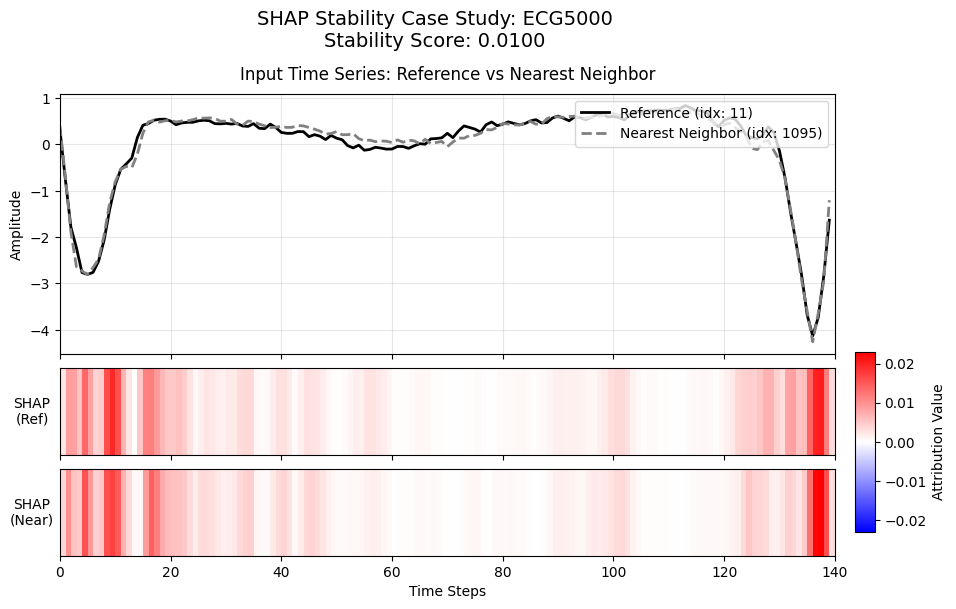

In [147]:
plot_explanation_comparison(
    testX, shap_values_test, reference_idx, near_idx_shap, stab_shap,
    dataset_path, TARGET_DATASET, "SHAP"
)

## LIME values

### LIME (Local Interpretable Model-agnostic Explanations)

**LIME** is a technique that explains the predictions of complex models ("black boxes") by learning a simple, interpretable surrogate model in the strict, local vicinity of the examined sample.

For sequential data (time series), LIME applies local perturbations to the original signal, observes how the underlying model's predictions change, and then fits a linear model weighted by the distance from the reference point. The weights of this linear model indicate which time steps had the greatest impact on driving the prediction toward a specific class.

In the following section, we apply the analogous stability metric (Lipschitz quotient) to examine whether local LIME surrogate models maintain consistency between nearest neighbors in the test set.

In [148]:
with open(os.path.join(dataset_path, 'lvts.pickle'), 'rb') as f:
    lime_values_test = pickle.load(f)

reference_idx = 11
near_idx_lime, in_dist_lime, exp_dist_lime, stab_lime = calculate_local_stability(testX, lime_values_test,
                                                                                  reference_idx)

print(f"Reference Instance Index: {reference_idx}")
print(f"Nearest Neighbor Index: {near_idx_lime}")
print(f"Distance in Input Space: {in_dist_lime:.4f}")
print(f"Distance in Explanation Space: {exp_dist_lime:.4f}")
print(f"Local Stability Score (Quotient): {stab_lime:.4f}\n")

Reference Instance Index: 11
Nearest Neighbor Index: 1095
Distance in Input Space: 1.5288
Distance in Explanation Space: 0.1073
Local Stability Score (Quotient): 0.0702



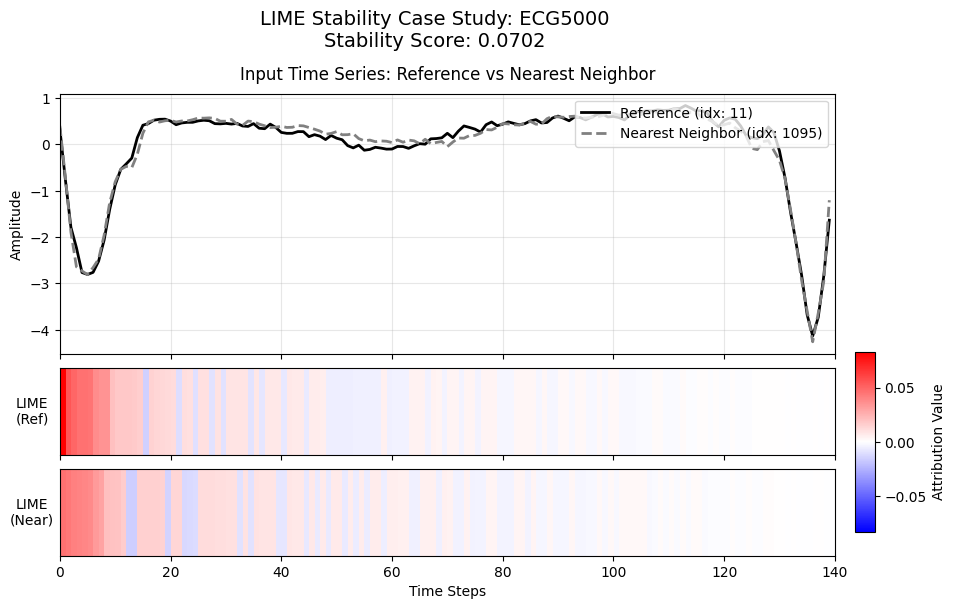

In [149]:
plot_explanation_comparison(
    testX, lime_values_test, reference_idx, near_idx_lime, stab_lime,
    dataset_path, TARGET_DATASET, "LIME"
)

## PHAR

### PHAR Explanations & Rule Stability Analysis

**PHAR (Post-hoc Attribution Rules)** is a framework that transforms numeric feature attributions from post-hoc, instance-wise explainers (such as LIME and SHAP) into structured, human-readable rules for time series classification. The full methodology is detailed in [Mozolewski et al., 2025](https://arxiv.org/abs/2508.01687).

PHAR identifies the most salient temporal intervals and translates them into interpretable "IF-THEN" rules that preserve the model's predicted class. Through controlled perturbation of important features, stable decision regions are derived. A condition for a given temporal feature $x_f$ is strictly defined as a half-open interval $(l_f, u_f]$ where $l_f$ is the lower bound and $u_f$ is the upper bound.

Key metrics evaluating a PHAR rule on the test set:
* **Confidence ($CONF$):** The proportion of instances satisfying the rule that are correctly classified as the reference class.
* **Coverage ($COV$):** The fraction of all instances that fall into the region defined by the rule's intervals.
* **Feature Count ($F(n)$):** The number of temporal features included in the rule, utilized to control rule complexity and cognitive interpretability.

To resolve rule ambiguity across different explainers, PHAR employs rule fusion strategies (e.g., Intersection, Union, Lasso, Best) to consolidate multiple rule sets into a single, optimized rule per instance.

#### Local Stability Score (Jaccard Index)
To evaluate local stability, we measure the overlap of the critical time steps extracted for the reference instance and its nearest neighbor in the input space using the **Jaccard Index** (Intersection over Union):

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

Where:
* $A$ – the set of constrained time steps forming the PHAR rule for the reference instance.
* $B$ – the set of constrained time steps forming the PHAR rule for the nearest neighbor.
* $|A \cap B|$ – the number of shared time steps between the two rules (intersection).
* $|A \cup B|$ – the total number of unique time steps across both rules combined (union).

**Interpretation:** The Jaccard Index ranges from $0.0$ to $1.0$. A score of $1.0$ means both the reference and the neighbor rely on the exact same set of temporal features (perfect local stability). A score of $0.0$ indicates completely disjoint rules.

In [150]:
# Load PHAR rules for the test set
with open(os.path.join(dataset_path, 'pvts.pickle'), 'rb') as f:
    phar_values_test = pickle.load(f)

# Unwrap the list of single-element lists format
phar_values_test = [r[0] for r in phar_values_test]
phar_values_test_valid_rules = [r for r in phar_values_test if r.get('success', False)]

print(f"Loaded {len(phar_values_test_valid_rules)} valid PHAR rules out of {len(phar_values_test)}.")

Loaded 1250 valid PHAR rules out of 1250.


In [151]:
# Load and beautifully display PHAR Metadata
metadata_path = os.path.join(dataset_path, 'phar_metadata.json')
with open(metadata_path, 'r', encoding='utf-8') as f:
    phar_metadata = json.load(f)

best_trial = phar_metadata.get('best_trial', {})
params = best_trial.get('params', {})
dyn_params = best_trial.get('dynamic_params', {})
metrics = best_trial.get('metrics', {})

print("\n" + "="*55)
print(f" PHAR METADATA SUMMARY: {phar_metadata.get('dataset_name', 'Unknown')}")
print("="*55)
print(f"Winning Base Explainer:    {params.get('explainer', 'N/A')}")
print(f"Threshold Percentile (p):  {params.get('threshold_percentile', 0.0):.2f}")
print(f"Perturb Sigma (sigma_p):   {params.get('perturb_sigma', 0.0):.2f}")
print(f"Global Importance (delta): {params.get('use_global_importance', False)}")
print(f"Perturbation Samples (Np): {dyn_params.get('perturbation_samples_count', 'N/A')}")

print("\nEstimated Metrics (from Optuna HPO):")
print(f" - Mean Confidence:        {metrics.get('confidence', {}).get('mean', 0.0):.4f}")
print(f" - Mean Coverage:          {metrics.get('coverage', {}).get('mean', 0.0):.4f}")
print(f" - Mean Sparsity:          {metrics.get('sparsity', {}).get('mean', 0.0):.2f} features")
print("="*55 + "\n")


 PHAR METADATA SUMMARY: ECG5000
Winning Base Explainer:    SHAP
Threshold Percentile (p):  34.36
Perturb Sigma (sigma_p):   0.82
Global Importance (delta): False
Perturbation Samples (Np): 1183

Estimated Metrics (from Optuna HPO):
 - Mean Confidence:        1.0000
 - Mean Coverage:          0.0068
 - Mean Sparsity:          94.76 features



In [152]:
def _extract_phar_indices(explanation: dict) -> list:
    """Helper to safely extract integer indices from PHAR rule keys."""
    if not explanation.get('success', False):
        return []

    indices = []
    for k in explanation.get('rule', {}).keys():
        if str(k).startswith('feature_'):
            indices.append(int(str(k).split('_')[1]))
        else:
            indices.append(int(k))
    return indices


def calculate_phar_stability(
        test_x: np.ndarray,
        phar_list: list,
        reference_idx: int
) -> Tuple[int, float]:
    """
    Calculates local stability for PHAR using the Jaccard Index.
    Returns the nearest neighbor index and the stability score.
    """
    x_flat = test_x.reshape(test_x.shape[0], -1)
    distances = np.linalg.norm(x_flat - x_flat[reference_idx], axis=1)
    nearest_idx = np.argsort(distances)[1]

    ref_exp = phar_list[reference_idx]
    near_exp = phar_list[nearest_idx]

    ref_success = ref_exp.get('success', False)
    near_success = near_exp.get('success', False)

    if not ref_success or not near_success:
        print("--- PHAR Local Stability ---")
        print(f"Stability cannot be calculated. Success status - Ref: {ref_success}, Near: {near_success}\n")
        return nearest_idx, np.nan

    ref_rule = set(_extract_phar_indices(ref_exp))
    near_rule = set(_extract_phar_indices(near_exp))

    intersection = len(ref_rule.intersection(near_rule))
    union = len(ref_rule.union(near_rule))
    jaccard_index = intersection / union if union > 0 else 0.0

    print("--- PHAR Local Stability ---")
    print(f"Reference Index: {reference_idx} | Rule length: {len(ref_rule)}")
    print(f"Nearest Neighbor: {nearest_idx} | Rule length: {len(near_rule)}")
    print(f"Shared Time Steps (Intersection): {intersection}")
    print(f"Local Stability Score (Jaccard Index): {jaccard_index:.4f}\n")

    return nearest_idx, jaccard_index


In [153]:
# Define the reference index
reference_idx = 11

near_idx_phar, stab_phar = calculate_phar_stability(testX, phar_values_test, reference_idx=reference_idx)

rule_indices = phar_values_test[reference_idx]
print(rule_indices)

--- PHAR Local Stability ---
Reference Index: 11 | Rule length: 106
Nearest Neighbor: 1095 | Rule length: 101
Shared Time Steps (Intersection): 88
Local Stability Score (Jaccard Index): 0.7395

{'index': 11, 'success': True, 'prediction': 1, 'rule': {'feature_0': ['>-0.6056893190752985', '<=1.2694404693590498'], 'feature_1': ['>-1.93231156212902', '<=0.4163897558621068'], 'feature_2': ['>-2.91550464374565', '<=-0.6613532212817232'], 'feature_6': ['>-3.3544286056638564', '<=-2.1689348403195297'], 'feature_7': ['>-3.0194607370130884', '<=-2.021286216197607'], 'feature_8': ['>-2.574148997211088', '<=-1.5546967560927405'], 'feature_9': ['>-1.931903851125823', '<=-0.8802765426352395'], 'feature_10': ['>-1.3468648725895214', '<=-0.40254059728428704'], 'feature_14': ['>-0.15813748407650016', '<=0.45072412119284094'], 'feature_15': ['>0.1065806348295932', '<=0.7199025043327575'], 'feature_16': ['>0.12921413240383028', '<=0.7701712765214206'], 'feature_17': ['>0.18830883924522446', '<=0.8562461

### Visualizing PHAR Rule Stability

The plot below visualizes the raw time series alongside the critical bounding intervals extracted by the PHAR algorithm. The rule intervals $x_f \in (l_f, u_f]$ are displayed directly on the signal to show where in the trace the decision is anchored.

**How to read the plot:**
* **Time Series:** The solid black line represents the reference instance, while the dotted gray line represents a counterfactual/nearest neighbor for contrast.
* **PHAR Rules (Intervals):** The extracted logical conditions are plotted as vertical bands at the constrained time indices.
    * **Solid Red Bands** indicate the valid feature range (lower and upper bounds) for the reference instance.
    * **Dashed Blue Bands** indicate the valid feature range for the nearest neighbor.
* **Interval Caps:** The horizontal markers at the top and bottom of each vertical segment denote the explicit $u_f$ and $l_f$ thresholds.

**Interpretation:** Overlapping bands across the reference and its neighbor indicate that the classifier relies on identical temporal segments and comparable value bounds for its predictions, resulting in a high Jaccard Index.

In [154]:
def _extract_phar_indices(explanation: dict) -> list:
    """
    Helper to safely extract feature identifiers for Jaccard Index.
    Using raw keys safely handles both univariate ('15', 'feature_15')
    and multivariate ('var_0_ts_15') formats.
    """
    if not explanation.get('success', False):
        return []
    return list(explanation.get('rule', {}).keys())


def _parse_phar_conditions(explanation: dict, target_channel: int = 0) -> List[Tuple[int, float, float]]:
    """
    Parses the PHAR rule dictionary into actionable logic limits (l, u].
    Filters conditions to only include those relevant to the target_channel.
    Returns a list of tuples: (time_step, lower_bound, upper_bound).
    """
    if not explanation.get('success', False):
        return []

    conditions = []
    rule_dict = explanation.get('rule', {})

    def clean_val(v):
        # Remove any logical operators and spaces before casting to float
        clean_str = str(v).replace('>', '').replace('<', '').replace('=', '').replace(' ', '')
        return float(clean_str)

    for feature, bounds in rule_dict.items():
        feature_str = str(feature)
        var_idx = 0
        time_step = 0

        # Handle multivariate format: var_0_ts_101
        if feature_str.startswith('var_'):
            parts = feature_str.split('_')
            var_idx = int(parts[1])
            time_step = int(parts[3])
        # Handle univariate formats: feature_15 or 15
        elif feature_str.startswith('feature_'):
            time_step = int(feature_str.split('_')[1])
        else:
            time_step = int(feature_str)

        # Only extract conditions for the channel we are currently plotting
        if var_idx != target_channel:
            continue

        l_val = clean_val(bounds[0])
        u_val = clean_val(bounds[1])
        conditions.append((time_step, l_val, u_val))

    return conditions


def plot_phar_rule_comparison(
        test_x: np.ndarray,
        phar_list: list,
        reference_idx: int,
        nearest_idx: int,
        dataset_path: str,
        dataset_name: str,
        channel_idx: int = 0
) -> None:
    """
    Visualizes the reference and nearest neighbor time series for a specific channel,
    plotting the two-sided PHAR intervals (l, u] matching the exact Anchor aesthetic.
    """
    ref_exp = phar_list[reference_idx]
    near_exp = phar_list[nearest_idx]

    if not ref_exp.get('success', False):
        print(f"Skipping plot: Reference index {reference_idx} lacks a successful PHAR rule.")
        return

    # Extract the specific channel for visualization
    ref_instance = test_x[reference_idx, :, channel_idx]
    near_instance = test_x[nearest_idx, :, channel_idx]

    # Parse conditions specific to the selected channel
    ref_conditions = _parse_phar_conditions(ref_exp, target_channel=channel_idx)
    near_conditions = _parse_phar_conditions(near_exp, target_channel=channel_idx) if near_exp.get('success',
                                                                                                   False) else []

    fig, ax = plt.subplots(figsize=(12, 5))

    # Plot the time series (Matching Anchor style: Black solid, Gray dashed)
    ax.plot(ref_instance, color="black", linewidth=2, label=f"Reference (idx: {reference_idx})")
    ax.plot(near_instance, color="gray", linestyle="--", linewidth=2, label=f"Nearest Neighbor (idx: {nearest_idx})")

    # Calculate limits to know where to draw the elements properly
    y_min, y_max = ax.get_ylim()
    margin = (y_max - y_min) * 0.1
    ax.set_ylim(y_min - margin, y_max + margin)

    # Helper function to draw the bounded intervals
    def draw_intervals(conditions, color, linestyle, label_prefix, offset=0):
        for i, (t, l_val, u_val) in enumerate(conditions):
            label = f"{label_prefix} Rule" if i == 0 else ""
            t_plot = t + offset

            # Draw the vertical range connecting l and u
            ax.vlines(x=t_plot, ymin=l_val, ymax=u_val, color=color, linestyle=linestyle, linewidth=2, alpha=0.8,
                      label=label)

            # Draw the top and bottom caps (solid lines for caps match Anchor's cap style)
            ax.hlines(y=u_val, xmin=t_plot - 0.1, xmax=t_plot + 0.1, color=color, linewidth=2, linestyle='solid')
            ax.hlines(y=l_val, xmin=t_plot - 0.1, xmax=t_plot + 0.1, color=color, linewidth=2, linestyle='solid')

    # Draw Reference rules (Solid red, matching Anchor)
    draw_intervals(ref_conditions, color="red", linestyle="-", label_prefix="Ref")

    # Draw Nearest Neighbor rules (Dashed gray, matching Anchor)
    if near_conditions:
        draw_intervals(near_conditions, color="gray", linestyle="--", label_prefix="Near",
                       offset=0.15)  # Slight offset to prevent visual overlap

    confidence = ref_exp.get('confidence', 0.0)
    coverage = ref_exp.get('coverage', 0.0)

    # Format title matching Anchor exactly
    channel_info = f" (Channel {channel_idx})" if test_x.shape[2] > 1 else ""
    ax.set_title(
        f"PHAR Explanation Comparison: {dataset_name}{channel_info}\nConfidence: {confidence:.2f} | Coverage: {coverage:.2f}",
        fontsize=12, pad=10)
    ax.set_ylabel("Amplitude")
    ax.set_xlabel("Time Steps")

    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper right")

    # Re-enable grid to match Anchor
    ax.grid(True, alpha=0.3)

    channel_suffix = f"_ch{channel_idx}" if test_x.shape[2] > 1 else ""
    fig_path = os.path.join(dataset_path, f"phar_casestudy_comparison_{dataset_name}{channel_suffix}.pdf")
    plt.savefig(fig_path, bbox_inches='tight', dpi=300)
    plt.show()

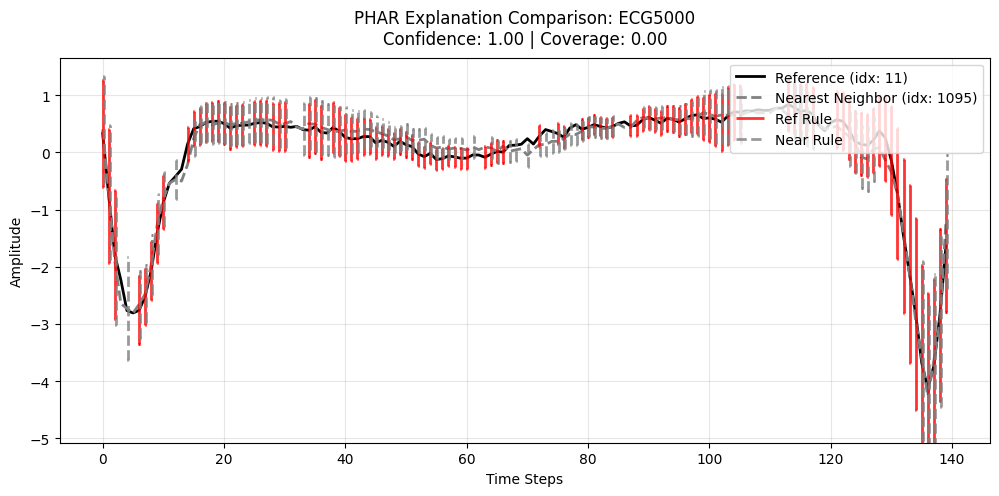

In [155]:
plot_phar_rule_comparison(
    test_x=testX,
    phar_list=phar_values_test,
    reference_idx=reference_idx,
    nearest_idx=near_idx_phar,
    dataset_path=dataset_path,
    dataset_name=TARGET_DATASET
)

## Anchor

### Anchor Explanations & Rule Stability Analysis

**Anchor** is a rule-based explanation method that, instead of assigning continuous attribution weights to features, identifies a minimal set of conditions (the "anchor") that sufficiently fixes the model's prediction locally. If the features in the anchor rule are met, the model will return the exact same prediction with a high probability, regardless of how the remaining, unanchored features are perturbed.

Key metrics defining an Anchor rule:
* **Precision:** The probability that the prediction holds true as long as the rule conditions are met.
* **Coverage:** The fraction of the overall dataset space to which the rule applies.

#### Local Stability Score (Jaccard Index)
Because Anchor outputs a discrete set of important features (specific time steps and their value thresholds) rather than a continuous vector of weights (like SHAP or LIME), calculating a Lipschitz-like continuous distance is not applicable. Instead, we evaluate local stability by measuring the overlap of the rules extracted for the reference instance and its nearest neighbor in the input space. We use the **Jaccard Index** (Intersection over Union) for this purpose:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

Where:
* $A$ – the set of time steps forming the anchor rule for the reference instance.
* $B$ – the set of time steps forming the anchor rule for the nearest neighbor.
* $|A \cap B|$ – the number of shared time steps between the two rules (intersection).
* $|A \cup B|$ – the total number of unique time steps across both rules combined (union).

**Interpretation:** The Jaccard Index ranges from $0.0$ to $1.0$. A score of $1.0$ means both the reference and the neighbor rely on the exact same set of features (perfect local stability). A score of $0.0$ indicates completely disjoint rules (poor stability), meaning the model shifts its entire reasoning despite the inputs being highly similar.

In [156]:
with open(os.path.join(dataset_path, 'avts.pickle'), 'rb') as f:
    anchor_values_test = pickle.load(f)

anchor_values_test = [r[0] for r in anchor_values_test]
anchor_values_test_valid_rules = [r for r in anchor_values_test if r['success']]

reference_idx = 11
rule_indices = anchor_values_test[reference_idx]
print(rule_indices)

{'index': 11, 'success': True, 'prediction': '1', 'rule': {'feature_9': ['<=-1.37'], 'feature_124': ['>-0.33'], 'feature_134': ['<=-2.71']}, 'anchor_method': 'alibi', 'anchor': ['feature_124 > -0.33', 'feature_134 <= -2.71', 'feature_9 <= -1.37'], 'confidence': 0.9900542495479204, 'coverage': 0.145, 'exp_count': 3}


In [157]:
def _extract_anchor_indices(explanation: dict) -> list:
    """Helper to safely extract integer indices from 'feature_X' keys."""
    if not explanation.get('success', False):
        return []

    # Extracts the integer (e.g., 33) from 'feature_33'
    return [int(k.split('_')[1]) for k in explanation.get('rule', {}).keys() if k.startswith('feature_')]


def calculate_anchor_stability(
        test_x: np.ndarray,
        anchors_list: list,
        reference_idx: int
) -> Tuple[int, float]:
    """
    Calculates local stability for Anchors using the Jaccard Index.
    Returns the nearest neighbor index and the stability score.
    """
    x_flat = test_x.reshape(test_x.shape[0], -1)
    distances = np.linalg.norm(x_flat - x_flat[reference_idx], axis=1)
    nearest_idx = np.argsort(distances)[1]

    ref_exp = anchors_list[reference_idx]
    near_exp = anchors_list[nearest_idx]

    if not ref_exp.get('success', False) or not near_exp.get('success', False):
        print("--- Anchor Local Stability ---")
        print(
            f"Stability cannot be calculated. Success status - Ref: {ref_exp.get('success')}, Near: {near_exp.get('success')}\n")
        return nearest_idx, np.nan

    ref_rule = set(_extract_anchor_indices(ref_exp))
    near_rule = set(_extract_anchor_indices(near_exp))

    intersection = len(ref_rule.intersection(near_rule))
    union = len(ref_rule.union(near_rule))
    jaccard_index = intersection / union if union > 0 else 0.0

    print("--- Anchor Local Stability ---")
    print(f"Reference Index: {reference_idx} | Rule length: {len(ref_rule)}")
    print(f"Nearest Neighbor: {nearest_idx} | Rule length: {len(near_rule)}")
    print(f"Shared Time Steps (Intersection): {intersection}")
    print(f"Local Stability Score (Jaccard Index): {jaccard_index:.4f}\n")

    return nearest_idx, jaccard_index

In [158]:
near_idx_anchor, stab_anchor = calculate_anchor_stability(testX, anchor_values_test, reference_idx=reference_idx)

--- Anchor Local Stability ---
Reference Index: 11 | Rule length: 3
Nearest Neighbor: 1095 | Rule length: 2
Shared Time Steps (Intersection): 2
Local Stability Score (Jaccard Index): 0.6667



### Visualizing Anchor Rule Stability

The plot below visualizes the raw time series alongside the critical logic thresholds extracted by the Anchor algorithm. This allows for a direct visual assessment of local explanation stability between the reference instance and its nearest neighbor.

**How to read the plot:**
* **Time Series:** The solid black line represents the reference instance, while the dashed gray line represents its nearest neighbor in the input space.
* **Anchor Rules (Rays):** The extracted logical conditions are plotted as directional rays (half-lines).
    * **Solid Red Rays** indicate the rule for the reference instance.
    * **Dashed Light Coral Rays** indicate the rule for the nearest neighbor.
* **Threshold Caps & Direction:** The small horizontal line (the "cap") marks the exact amplitude threshold of the rule (e.g., `-0.99`). The vertical ray pointing downwards indicates a "less than or equal to" ($\leq$) condition, whereas a ray pointing upwards indicates a "greater than or equal to" ($\geq$) condition.

**Interpretation:** Visually, a highly stable explanation will show the red and dashed coral rays overlapping at the exact same time steps with similar directional logic. If the rays are scattered across completely different time steps, it indicates that the model relies on entirely different temporal features for nearly identical inputs, resulting in a low Jaccard Index and poor local stability.

In [159]:
def _parse_anchor_conditions(explanation: dict) -> List[Tuple[int, str, float]]:
    """
    Safely parses the Anchor rule dictionary into actionable logic limits.
    Returns a list of tuples: (time_step, operator, threshold_value).
    """
    if not explanation.get('success', False):
        return []

    conditions = []
    rule_dict = explanation.get('rule', {})

    for feature, conditions_list in rule_dict.items():
        if not feature.startswith('feature_'):
            continue

        time_step = int(feature.split('_')[1])

        # Alibi outputs conditions as lists of strings, e.g., ['<=-0.99'] or ['>-0.52', '<=0.99']
        for cond_str in conditions_list:
            if cond_str.startswith('<='):
                conditions.append((time_step, '<=', float(cond_str[2:])))
            elif cond_str.startswith('>='):
                conditions.append((time_step, '>=', float(cond_str[2:])))
            elif cond_str.startswith('<'):
                conditions.append((time_step, '<', float(cond_str[1:])))
            elif cond_str.startswith('>'):
                conditions.append((time_step, '>', float(cond_str[1:])))

    return conditions


def plot_anchor_rule_comparison(
        test_x: np.ndarray,
        anchors_list: list,
        reference_idx: int,
        nearest_idx: int,
        dataset_path: str,
        dataset_name: str
) -> None:
    """
    Visualizes the reference and nearest neighbor time series,
    plotting the Anchor thresholds as directional rays (half-lines).
    """
    ref_exp = anchors_list[reference_idx]
    near_exp = anchors_list[nearest_idx]

    if not ref_exp.get('success', False):
        print(f"Skipping plot: Reference index {reference_idx} lacks a successful Anchor rule.")
        return

    ref_instance = test_x[reference_idx, :, 0]
    near_instance = test_x[nearest_idx, :, 0]

    ref_conditions = _parse_anchor_conditions(ref_exp)
    near_conditions = _parse_anchor_conditions(near_exp) if near_exp.get('success', False) else []

    fig, ax = plt.subplots(figsize=(12, 5))

    # Plot the time series
    ax.plot(ref_instance, color="black", linewidth=2, label=f"Reference (idx: {reference_idx})")
    ax.plot(near_instance, color="gray", linestyle="--", linewidth=2, label=f"Nearest Neighbor (idx: {nearest_idx})")

    # Calculate limits to know where to draw the rays
    y_min, y_max = ax.get_ylim()
    # Add a little padding to the limits so rays don't end exactly on the plot border
    margin = (y_max - y_min) * 0.1
    ax.set_ylim(y_min - margin, y_max + margin)
    y_lim_bottom, y_lim_top = ax.get_ylim()

    # Helper function to draw the rays
    def draw_rays(conditions, color, linestyle, label_prefix):
        for i, (t, op, val) in enumerate(conditions):
            label = f"{label_prefix} Rule" if i == 0 else ""

            # Draw the threshold cap (horizontal line)
            ax.hlines(y=val, xmin=t - 0.1, xmax=t + 0.1, color=color, linewidth=2, linestyle='solid')

            # Draw the directional ray (half-line)
            if op in ['<=', '<']:
                ax.vlines(x=t, ymin=y_lim_bottom, ymax=val, color=color, linestyle=linestyle, linewidth=2, alpha=0.8,
                          label=label)
            elif op in ['>=', '>']:
                ax.vlines(x=t, ymin=val, ymax=y_lim_top, color=color, linestyle=linestyle, linewidth=2, alpha=0.8,
                          label=label)

            # Plot the actual feature point of the instance to see if it falls within the rule
            # (Only really useful if we want to see where the signal is relative to the cap)
            # ax.plot(t, val, marker='o', color=color, markersize=5)

    # Draw Reference rules (Solid red)
    draw_rays(ref_conditions, color="red", linestyle="-", label_prefix="Ref")

    # Draw Nearest Neighbor rules (Dashed light coral)
    if near_conditions:
        draw_rays(near_conditions, color="gray", linestyle="--", label_prefix="Near")

    precision = ref_exp.get('confidence', 0.0)
    coverage = ref_exp.get('coverage', 0.0)

    ax.set_title(
        f"Anchor Explanation Comparison: {dataset_name}\nPrecision: {precision:.2f} | Coverage: {coverage:.2f}",
        fontsize=12, pad=10)
    ax.set_ylabel("Amplitude")
    ax.set_xlabel("Time Steps")

    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper right")

    ax.grid(True, alpha=0.3)

    fig_path = os.path.join(dataset_path, f"anchor_casestudy_comparison_{dataset_name}.pdf")
    plt.savefig(fig_path, bbox_inches='tight', dpi=300)
    plt.show()

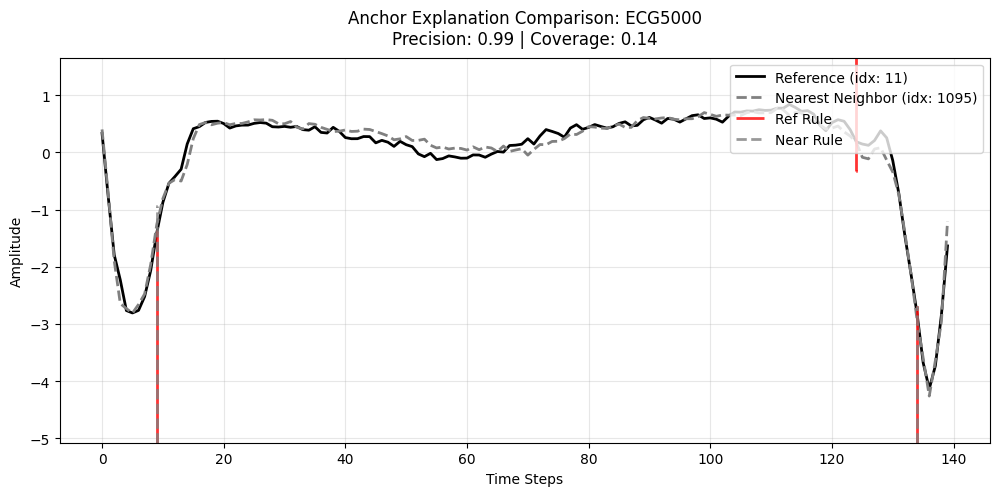

In [160]:
plot_anchor_rule_comparison(
    test_x=testX,
    anchors_list=anchor_values_test,
    reference_idx=reference_idx,
    nearest_idx=near_idx_anchor,
    dataset_path=dataset_path,
    dataset_name=TARGET_DATASET
)

# Export all models Acc

In [ ]:
def extract_dataset_metrics(dataset_path: str, dataset_name: str, dataset_type: str) -> Dict[str, Any]:
    """
    Loads test artifacts and the corresponding pre-trained model to extract metrics.
    Gracefully handles missing model.h5 files by returning None for evaluation metrics.
    """
    with open(os.path.join(dataset_path, 'testX.pickle'), 'rb') as f:
        X_test = pickle.load(f)

    with open(os.path.join(dataset_path, 'testy.pickle'), 'rb') as f:
        y_test = pickle.load(f)

    # Always extract dataset structure info
    y_true_classes = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test
    unique_classes = np.unique(y_true_classes)
    timesteps = X_test.shape[1]
    channels = X_test.shape[2] if len(X_test.shape) > 2 else 1

    input_dim = X_test.shape[1:]
    n_classes = y_test.shape[1] if len(testy.shape) > 1 else len(np.unique(testy))

    metrics = {
        "Dataset": dataset_name,
        "Type": dataset_type,
        "Classes": len(unique_classes),
        "Test_Samples": X_test.shape[0],
        "Timesteps": timesteps,
        "Channels": channels,
        "Test_Accuracy": None,
        "Test_F1_Weighted": None,
        "Test_Precision_Weighted": None,
        "Test_Recall_Weighted": None
    }

    # Attempt to evaluate the model
    try:
        # Automatically handles H5, SavedModel (model_tf/1) and legacy compatibility
        model = load_benchmark_model(dataset_path, input_shape=input_dim, num_classes=n_classes)
        y_pred_proba = model.predict(X_test, verbose=0)
        y_pred_classes = np.argmax(y_pred_proba, axis=1)

        metrics["Test_Accuracy"] = accuracy_score(y_true_classes, y_pred_classes)
        metrics["Test_F1_Weighted"] = f1_score(y_true_classes, y_pred_classes, average='weighted')
        metrics["Test_Precision_Weighted"] = precision_score(y_true_classes, y_pred_classes, average='weighted',
                                                             zero_division=0)
        metrics["Test_Recall_Weighted"] = recall_score(y_true_classes, y_pred_classes, average='weighted',
                                                       zero_division=0)

    except (FileNotFoundError, OSError):
        # Catch OSError as well, since h5py raises it when file is missing/corrupted
        print(f" [!] Missing or corrupted model for {dataset_name}. Storing structure only.")

    return metrics


def compile_all_model_evaluations(uni_dir: str, multi_dir: str) -> pd.DataFrame:
    """
    Iterates over all datasets to compile metadata and evaluation metrics.
    """
    results = []

    # Process Univariate
    for ds_name in [f.name for f in os.scandir(uni_dir) if f.is_dir() and not f.name.startswith('.')]:
        ds_path = os.path.join(uni_dir, ds_name)
        print(f"Evaluating {ds_name} (Univariate)...")
        results.append(extract_dataset_metrics(ds_path, ds_name, "Univariate"))

    # Process Multivariate
    for ds_name in [f.name for f in os.scandir(multi_dir) if f.is_dir() and not f.name.startswith('.')]:
        ds_path = os.path.join(multi_dir, ds_name)
        print(f"Evaluating {ds_name} (Multivariate)...")
        results.append(extract_dataset_metrics(ds_path, ds_name, "Multivariate"))

    return pd.DataFrame(results)


# Execute the extraction pipeline
df_evaluations = compile_all_model_evaluations(UNI_DIR, MULTI_DIR)

# Sort logically for presentation
df_evaluations.sort_values(by=["Type", "Dataset"], inplace=True)

In [27]:
missing_datasets = df_evaluations[df_evaluations["Test_Accuracy"].isna()]
display(missing_datasets[["Dataset", "Type", "Test_Samples", "Timesteps", "Channels"]])

,Dataset,Type,Test_Samples,Timesteps,Channels


In [28]:
df_evaluations

,Dataset,Type,Classes,Test_Samples,Timesteps,Channels,Test_Accuracy,Test_F1_Weighted,Test_Precision_Weighted,Test_Recall_Weighted
84,ArticularyWordRecognition,Multivariate,25,144,144,9,0.972222,0.973491,0.980035,0.972222
97,AtrialFibrillation,Multivariate,3,8,640,2,0.500000,0.412500,0.535714,0.500000
86,BasicMotions,Multivariate,4,20,100,6,1.000000,1.000000,1.000000,1.000000
99,Cricket,Multivariate,12,45,1197,6,0.911111,0.906936,0.931111,0.911111
92,ERing,Multivariate,6,75,65,4,0.960000,0.960112,0.967500,0.960000
...,...,...,...,...,...,...,...,...,...,...
57,Wine,Univariate,2,28,234,1,0.607143,0.458730,0.368622,0.607143
80,WordSynonyms,Univariate,25,227,270,1,0.678414,0.667364,0.694842,0.678414
39,Worms,Univariate,5,65,900,1,0.523077,0.526545,0.579878,0.523077
17,WormsTwoClass,Univariate,2,65,900,1,0.507692,0.507692,0.507692,0.507692


In [ ]:
csv_output_path = os.path.join(BASE_PATH, "recalculated_model_evaluations_fin.csv")
df_evaluations.to_csv(csv_output_path, index=False)
print(f"\nSuccessfully saved evaluation results to: {csv_output_path}")